In [1]:
!git clone https://github.com/eliftufekci/k_shortest_path_with_diversity.git

Cloning into 'k_shortest_path_with_diversity'...
remote: Enumerating objects: 500, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 500 (delta 7), reused 0 (delta 0), pack-reused 474 (from 1)
Receiving objects: 100% (500/500), 1.29 MiB | 11.32 MiB/s, done.
Resolving deltas: 100% (319/319), done.


In [2]:
import sys

top_level_container_dir = "k_shortest_path_with_diversity/"

if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

In [3]:
import gc
import networkx as nx
import random
import datetime
import numpy as np

from k_shortest_path_with_diversity.examples import draw_bar_chart, download_and_prepare_graphs
from k_shortest_path_with_diversity.examples.draw_distribution import draw_time_distribution, draw_num_of_path_distribution
from k_shortest_path_with_diversity.src.algorithms import FindKSPD, FindKSPD_Yen, FindKSPD_Minus

In [4]:
def run_algorithm(algorithm, G, threshold, k, node_pairs):
    times = []
    num_paths = []

    for src, dest in node_pairs:
        print(f"\nComparing algorithms for SRC: {src}, DEST: {dest}")

        start_time = datetime.datetime.now()
        alg = algorithm(G, threshold)
        result = alg.find_paths(src=src, dest=dest, k=k)
        end_time = datetime.datetime.now()
        execution_time = end_time - start_time

        times.append(execution_time.total_seconds())
        num_paths.append(alg.number_of_paths_explored)


    return times, num_paths

In [5]:
def upload_graph(filepath, num_pairs):
    G = nx.DiGraph()
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:  # Weighted graph (3 parçalı satır: kaynak, hedef, ağırlık)
                u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
                G.add_edge(u, v, weight=weight)
            elif len(parts) == 2:  # Unweighted graph (2 parçalı satır: kaynak ve hedef)
                u, v = map(int, parts)
                G.add_edge(u, v, weight=1)  # Ağırlıksız kenarları varsayılan olarak '1' ağırlıkla ekle
            else:
                raise ValueError("Unexpected line format in graph file.")

    node_pairs = []
    for _ in range(num_pairs):
        src = random.choice(list(G.nodes()))
        reachable = list(nx.descendants(G, src))

        while not reachable:
            src = random.choice(list(G.nodes()))
            reachable = list(nx.descendants(G, src))

        dest = random.choice(reachable)
        node_pairs.append((src, dest))

    return G, node_pairs

In [6]:
download_and_prepare_graphs()

k_to_find = 10
diversity_threshold = 0.6

Downloading: https://snap.stanford.edu/data/web-Google.txt.gz
Extracting: /content/graph-data/web-Google.txt.gz -> /content/graph-data/web-Google.txt
Removed archive: /content/graph-data/web-Google.txt.gz
Done: /content/graph-data/web-Google.txt
Downloading: https://snap.stanford.edu/data/wiki-Talk.txt.gz
Extracting: /content/graph-data/wiki-Talk.txt.gz -> /content/graph-data/wiki-Talk.txt
Removed archive: /content/graph-data/wiki-Talk.txt.gz
Done: /content/graph-data/wiki-Talk.txt
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.FLA.gr.gz
Extracting: /content/graph-data/USA-road-d.FLA.gr.gz -> /content/graph-data/USA-road-d.FLA.gr
Removed archive: /content/graph-data/USA-road-d.FLA.gr.gz
Done: /content/graph-data/USA-road-d.FLA.gr
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.COL.gr.gz
Extracting: /content/graph-data/USA-road-d.COL.gr.gz -> /content/graph-data/USA-road-d.COL.gr
Removed archive: /content/graph-data/USA-ro

In [7]:
web_google_path = "/content/graph-data/web-Google.txt"
num_pairs = 20
G, node_pairs = upload_graph(web_google_path, num_pairs)

print(node_pairs)

[(884816, 280162), (875774, 659660), (511587, 372382), (671988, 441285), (3181, 378795), (343735, 578423), (682512, 823861), (232330, 238595), (192678, 881765), (461139, 85124), (528367, 889590), (564718, 633573), (485890, 336400), (314130, 749481), (633158, 826378), (285388, 743523), (710717, 687427), (890845, 793487), (105254, 749050), (589292, 291937)]


In [8]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 884816, DEST: 280162

Comparing algorithms for SRC: 875774, DEST: 659660

Comparing algorithms for SRC: 511587, DEST: 372382

Comparing algorithms for SRC: 671988, DEST: 441285

Comparing algorithms for SRC: 3181, DEST: 378795

Comparing algorithms for SRC: 343735, DEST: 578423

Comparing algorithms for SRC: 682512, DEST: 823861

Comparing algorithms for SRC: 232330, DEST: 238595

Comparing algorithms for SRC: 192678, DEST: 881765

Comparing algorithms for SRC: 461139, DEST: 85124

Comparing algorithms for SRC: 528367, DEST: 889590

Comparing algorithms for SRC: 564718, DEST: 633573

Comparing algorithms for SRC: 485890, DEST: 336400

Comparing algorithms for SRC: 314130, DEST: 749481

Comparing algorithms for SRC: 633158, DEST: 826378

Comparing algorithms for SRC: 285388, DEST: 743523

Comparing algorithms for SRC: 710717, DEST: 687427

Comparing algorithms for SRC: 890845, DEST: 793487

Comparing algorithms for SRC: 105254, DEST: 7490

In [9]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 884816, DEST: 280162

Comparing algorithms for SRC: 875774, DEST: 659660

Comparing algorithms for SRC: 511587, DEST: 372382

Comparing algorithms for SRC: 671988, DEST: 441285

Comparing algorithms for SRC: 3181, DEST: 378795

Comparing algorithms for SRC: 343735, DEST: 578423

Comparing algorithms for SRC: 682512, DEST: 823861

Comparing algorithms for SRC: 232330, DEST: 238595

Comparing algorithms for SRC: 192678, DEST: 881765

Comparing algorithms for SRC: 461139, DEST: 85124

Comparing algorithms for SRC: 528367, DEST: 889590

Comparing algorithms for SRC: 564718, DEST: 633573

Comparing algorithms for SRC: 485890, DEST: 336400

Comparing algorithms for SRC: 314130, DEST: 749481

Comparing algorithms for SRC: 633158, DEST: 826378

Comparing algorithms for SRC: 285388, DEST: 743523

Comparing algorithms for SRC: 710717, DEST: 687427

Comparing algorithms for SRC: 890845, DEST: 793487

Comparing algorithms for SRC: 105254, DEST

In [ ]:
print("working with KSPD_Yen")
kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

# kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
# kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

# kspd_yen_avg_time = 10**6
# kspd_yen_avg_num_paths =  10**6

working with KSPD_Yen

Comparing algorithms for SRC: 884816, DEST: 280162


In [ ]:
web_google_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(web_google_result)

((33.80602562, 102.94, [38.27031, 31.848766, 43.04204, 36.185116, 40.8018, 22.586582, 49.404681, 23.651227, 25.749549, 30.751324, 40.314198, 14.135857, 16.310595, 41.880111, 33.278707, 25.322987, 35.24834, 37.203676, 27.247212, 33.551702, 42.328935, 29.537775, 42.94143, 29.821793, 40.890255, 23.092307, 35.903322, 44.837056, 31.010624, 25.534183, 41.998205, 14.871176, 27.567122, 39.828532, 14.449758, 51.457984, 31.874304, 19.888274, 42.424286, 23.61911, 58.626632, 41.029796, 58.960803, 34.356953, 23.593159, 31.356939, 26.31606, 35.737736, 45.801423, 33.860569], [217, 192, 86, 73, 170, 9, 313, 1, 74, 69, 63, 1, 1, 33, 48, 33, 64, 76, 29, 89, 29, 21, 23, 92, 329, 81, 58, 92, 94, 37, 55, 1, 98, 98, 0, 251, 9, 9, 80, 79, 382, 47, 634, 143, 8, 90, 123, 69, 382, 92]), (42.414587000000004, 170.84, [42.953419, 28.752677, 38.037982, 38.284835, 296.406845, 23.376331, 185.595699, 23.913728, 27.765227, 28.336871, 42.169397, 15.327361, 14.62427, 41.442467, 34.096862, 23.813779, 35.292155, 39.165742,

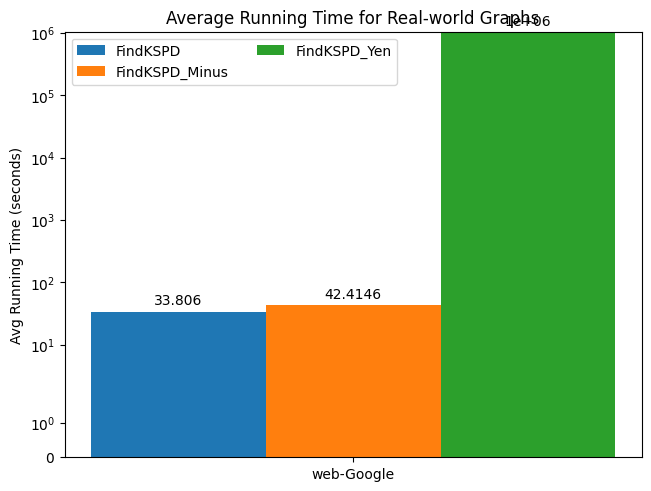

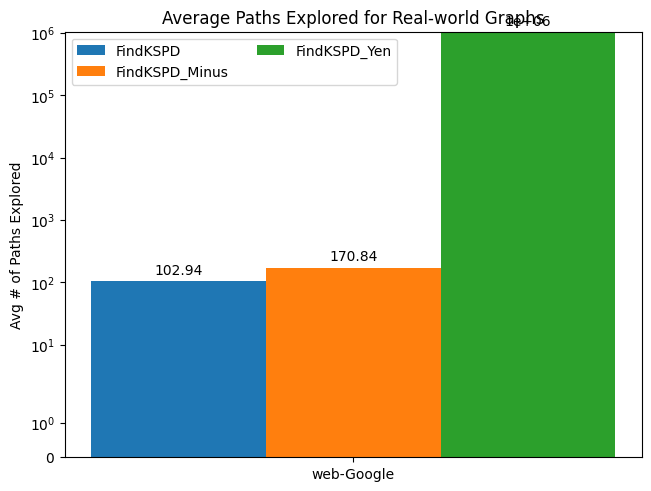

In [ ]:
graph_types = ("web-Google",)

algorithms_time = {
    'FindKSPD':       [web_google_result[0][0]],  # index 0 = avg_time
    'FindKSPD_Minus': [web_google_result[1][0]],
    'FindKSPD_Yen':   [web_google_result[2][0]],
}

algorithms_paths = {
    'FindKSPD':       [web_google_result[0][1]],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [web_google_result[1][1]],
    'FindKSPD_Yen':   [web_google_result[2][1]],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

1465119

In [ ]:
wiki_talk_path  = "/content/graph-data/wiki-Talk.txt"
num_pairs = 50
G, node_pairs = upload_graph(wiki_talk_path, num_pairs)
print(node_pairs)

[(1097683, 86067), (669559, 865600), (705316, 662584), (324635, 1670237), (1022511, 2136983), (29708, 1028772), (844540, 685886), (1479118, 2092000), (26419, 517379), (10126, 2131555), (941161, 1543087), (355991, 355992), (1714646, 2211226), (164738, 778382), (1473759, 1473760), (720947, 1101435), (34030, 1200848), (803603, 86482), (38144, 1246382), (34369, 1039200), (449034, 1796485), (274620, 125880), (8534, 1759956), (45648, 7993), (262683, 361345), (118864, 2132405), (745023, 745024), (1130146, 1271398), (237124, 753773), (68689, 1273959), (188292, 232407), (53361, 2380098), (83634, 1508256), (1342417, 1801208), (478246, 1407796), (739368, 2243766), (72418, 1027720), (49701, 1885897), (10135, 828178), (166043, 104764), (683281, 2151883), (79134, 2220161), (745793, 1567831), (485469, 2188470), (1151567, 1151568), (40165, 960284), (904849, 1881398), (1008197, 380501), (94631, 424112), (466002, 678138)]


In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 1097683, DEST: 86067

Comparing algorithms for SRC: 669559, DEST: 865600

Comparing algorithms for SRC: 705316, DEST: 662584

Comparing algorithms for SRC: 324635, DEST: 1670237

Comparing algorithms for SRC: 1022511, DEST: 2136983

Comparing algorithms for SRC: 29708, DEST: 1028772

Comparing algorithms for SRC: 844540, DEST: 685886

Comparing algorithms for SRC: 1479118, DEST: 2092000

Comparing algorithms for SRC: 26419, DEST: 517379

Comparing algorithms for SRC: 10126, DEST: 2131555

Comparing algorithms for SRC: 941161, DEST: 1543087

Comparing algorithms for SRC: 355991, DEST: 355992

Comparing algorithms for SRC: 1714646, DEST: 2211226

Comparing algorithms for SRC: 164738, DEST: 778382

Comparing algorithms for SRC: 1473759, DEST: 1473760

Comparing algorithms for SRC: 720947, DEST: 1101435

Comparing algorithms for SRC: 34030, DEST: 1200848

Comparing algorithms for SRC: 803603, DEST: 86482

Comparing algorithms for SRC: 38144,

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 1097683, DEST: 86067

Comparing algorithms for SRC: 669559, DEST: 865600

Comparing algorithms for SRC: 705316, DEST: 662584

Comparing algorithms for SRC: 324635, DEST: 1670237

Comparing algorithms for SRC: 1022511, DEST: 2136983

Comparing algorithms for SRC: 29708, DEST: 1028772

Comparing algorithms for SRC: 844540, DEST: 685886

Comparing algorithms for SRC: 1479118, DEST: 2092000

Comparing algorithms for SRC: 26419, DEST: 517379

Comparing algorithms for SRC: 10126, DEST: 2131555

Comparing algorithms for SRC: 941161, DEST: 1543087

Comparing algorithms for SRC: 355991, DEST: 355992

Comparing algorithms for SRC: 1714646, DEST: 2211226

Comparing algorithms for SRC: 164738, DEST: 778382

Comparing algorithms for SRC: 1473759, DEST: 1473760

Comparing algorithms for SRC: 720947, DEST: 1101435

Comparing algorithms for SRC: 34030, DEST: 1200848

Comparing algorithms for SRC: 803603, DEST: 86482

Comparing algorithms for SRC: 

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
wiki_talk_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(wiki_talk_result)

((50.48264932000001, 8.12, [59.330221, 49.562702, 49.647377, 44.913324, 83.591507, 43.312283, 48.953191, 63.299743, 48.339551, 55.329119, 58.770335, 12.178463, 63.059564, 41.5997, 14.84881, 53.518094, 46.391145, 43.967704, 67.563499, 52.531384, 38.484368, 47.623862, 55.203778, 39.542725, 42.505075, 64.669868, 17.8713, 20.209406, 39.523541, 59.34774, 52.582769, 64.089025, 57.556051, 62.125853, 59.313383, 66.879651, 52.098893, 83.745911, 48.098059, 48.05873, 86.164034, 63.063001, 40.20295, 37.943412, 20.099613, 56.182632, 58.937315, 48.650476, 38.828307, 53.823022], [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0, 9, 9, 0, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0, 1, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0, 9, 9, 9, 9, 9]), (np.float64(70.15056668), np.float64(8.12), [85.20415, 76.710121, 68.102596, 59.641146, 112.455145, 66.944085, 76.723763, 84.495967, 69.657186, 88.627594, 76.675766, 26.688504, 83.718944, 63.220971, 22.296449, 79.744442, 67.488228, 67.011456, 75.521639, 65.329903, 53.205044, 

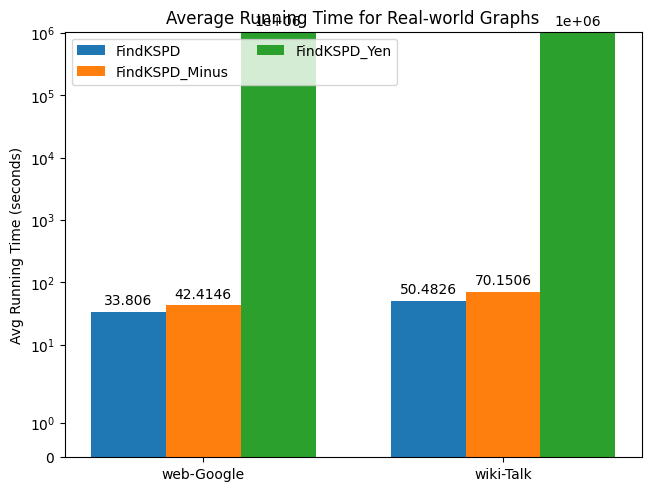

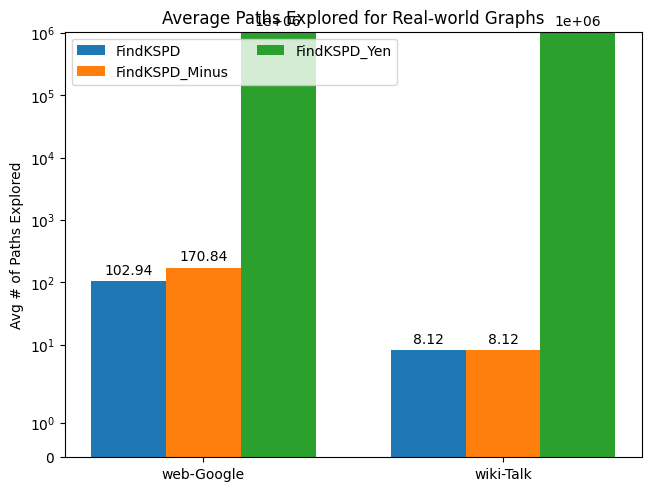

In [ ]:
all_results = [web_google_result, wiki_talk_result]

graph_types = ("web-Google", "wiki-Talk")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

2525579

In [ ]:
roadCOL_path    = "/content/graph-data/USA-road-d.COL.gr"
num_pairs = 1
G, node_pairs = upload_graph(roadCOL_path, num_pairs)
print(node_pairs)

[(251936, 244301)]


In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 251936, DEST: 244301


In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadCOL_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(roadCOL_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadCOL_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
roadFLA_path = "/content/graph-data/USA-road-d.FLA.gr"
num_pairs = 5
G, node_pairs = upload_graph(roadFLA_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadFLA_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(roadFLA_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadCOL_result, roadFLA_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL", "RoadFLA")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
all_kspd_times = []
all_kspd_minus_times = []
all_kspd_yen_times = []

all_kspd_num_paths = []
all_kspd_minus_num_paths = []
all_kspd_yen_num_paths = []

for graph_result in all_results:
    all_kspd_times.extend(graph_result[0][2])
    all_kspd_num_paths.extend(graph_result[0][3])

    all_kspd_minus_times.extend(graph_result[1][2])
    all_kspd_minus_num_paths.extend(graph_result[1][3])

    all_kspd_yen_times.extend(graph_result[2][2])
    all_kspd_yen_num_paths.extend(graph_result[2][3])

# Plotting distributions for times
plot_configs_time = [
    ('FindKSPD Execution Times', all_kspd_times, 'skyblue'),
    ('FindKSPD_Minus Execution Times', all_kspd_minus_times, 'lightcoral'),
    ('FindKSPD_Yen Execution Times', all_kspd_yen_times, 'lightgreen'),
]
draw_time_distribution(plot_configs_time)

# Plotting distributions for number of paths
plot_configs_num_paths = [
    ('FindKSPD Number of Paths Explored', all_kspd_num_paths, 'skyblue'),
    ('FindKSPD_Minus Number of Paths Explored', all_kspd_minus_num_paths, 'lightcoral'),
    ('FindKSPD_Yen Number of Paths Explored', all_kspd_yen_num_paths, 'lightgreen'),
]
draw_num_of_path_distribution(plot_configs_num_paths)